In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl
from smarts_cerebellum.util import process_df

In [2]:
tract = 'MCP'

T1  = pd.read_csv(os.path.join(gl.baseDir, 'regression', f'summary_MNISymC_{tract}_T1_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', f'summary_MNISymC_{tract}_GM_mod_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
WM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', f'summary_MNISymC_{tract}_WM_mod_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CSF = pd.read_csv(os.path.join(gl.baseDir, 'regression', f'summary_MNISymC_{tract}_CSF_mod_slope.tsv'), sep = '\t')  # slope for each subject at L/R CST


t1_r_patients, t1_l_patients, t1_bilat_controls, t1 = process_df.tract_df(T1, tract = tract)
wm_r_patients, wm_l_patients, wm_bilat_controls, wm = process_df.tract_df(WM, tract = tract)
gm_r_patients, gm_l_patients, gm_bilat_controls, gm = process_df.tract_df(GM, tract = tract)
csf_r_patients, csf_l_patients, csf_bilat_controls, csf = process_df.tract_df(CSF, tract = tract)


# controls to possibly exclude: JHP_1004; UZP_1006; UZP_1001

**t-test for T1 MCP: lesion side in patients, controls** 
 t-value: -1.1541683607527735 	 p-value: 0.2545240491748107


**t-test for T1 MCP: non-lesion side in patients, controls** 
 t-value: -0.4102339700760479 	 p-value: 0.683580981506619


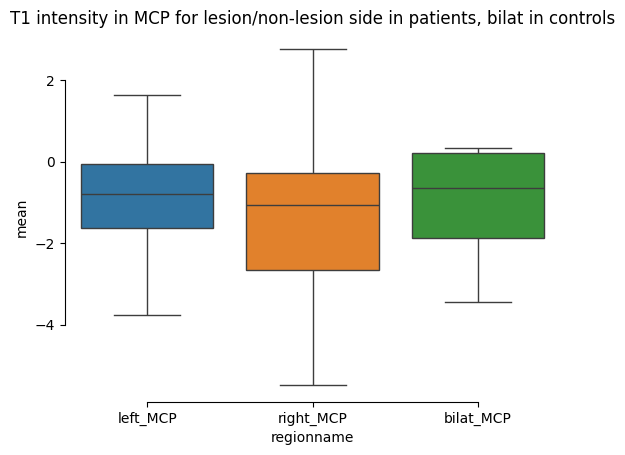

In [19]:
t_val, p_val = stats.ttest_ind(t1_r_patients, t1_bilat_controls)
print(f'**t-test for T1 {tract}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(t1_l_patients, t1_bilat_controls)
print(f'**t-test for T1 {tract}: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=t1, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title(f'T1 intensity in {tract} for lesion/non-lesion side in patients, bilat in controls')
plt.show()

In [4]:
t_val, p_val = stats.ttest_rel(t1_r_patients, t1_l_patients)
print(f'**t-test for {tract}: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

**t-test for MCP: within patients, left, right hemispheres** 
 t-value: -1.6367446214450252 	 p-value: 0.11064569671535866




**one-sided t-test for WM MCP: lesion side in patients, controls** 
 t-value: -2.137113473665973 	 p-value: 0.01902950130571012


**one-sided t-test for WM CSMCPT: non-lesion side in patients, controls** 
 t-value: -3.1078292438196686 	 p-value: 0.0016309294688127138


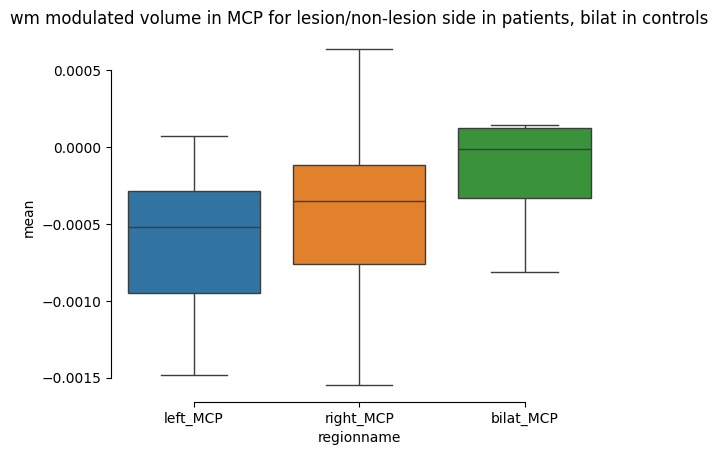

In [25]:
t_val, p_val = stats.ttest_ind(wm_r_patients, wm_bilat_controls, alternative = 'less')
print(f'**one-sided t-test for WM {tract}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(wm_l_patients, wm_bilat_controls, alternative = 'less')
print(f'**one-sided t-test for WM CS{tract}T: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=wm, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title(f'wm modulated volume in {tract} for lesion/non-lesion side in patients, bilat in controls')
plt.show()

**t-test for GM MCP: lesion side in patients, controls** 
 t-value: 2.0802721297578692 	 p-value: 0.021612326328866237


**t-test for GM MCP: non-lesion side in patients, controls** 
 t-value: 2.015869699859207 	 p-value: 0.02490390863105424


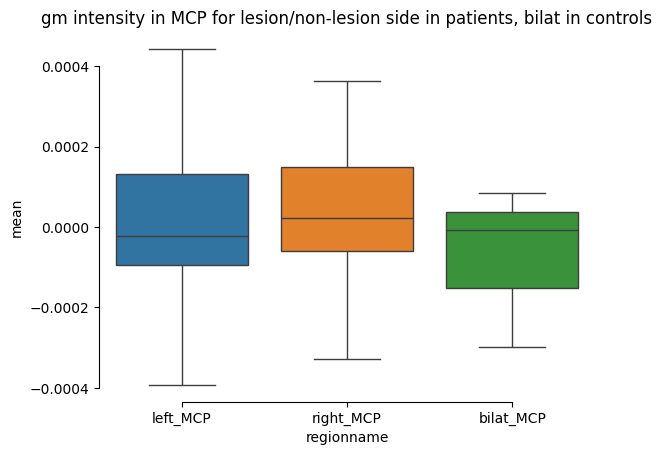

In [22]:
t_val, p_val = stats.ttest_ind(gm_r_patients, gm_bilat_controls, alternative = 'greater')
print(f'**t-test for GM {tract}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(gm_l_patients, gm_bilat_controls, alternative = 'greater')
print(f'**t-test for GM {tract}: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=gm, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title(f'gm intensity in {tract} for lesion/non-lesion side in patients, bilat in controls')
plt.show()

**t-test for CSF MCP: lesion side in patients, controls** 
 t-value: -0.31385993105249765 	 p-value: 0.7550778007710981


**t-test for CSF MCP: non-lesion side in patients, controls** 
 t-value: -0.025222796318942437 	 p-value: 0.9799887749715778


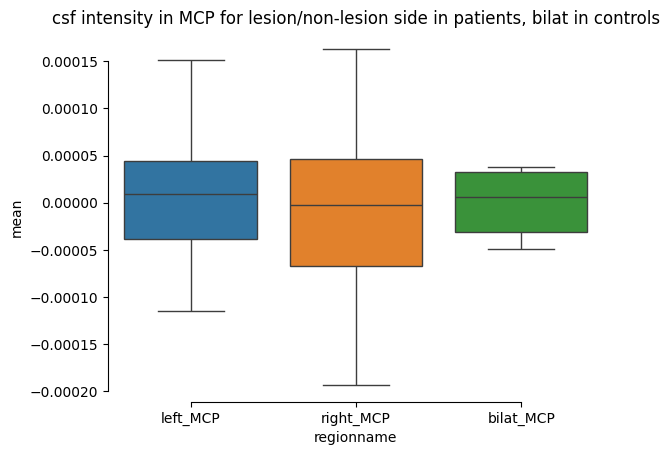

In [23]:
t_val, p_val = stats.ttest_ind(csf_r_patients, csf_bilat_controls)
print(f'**t-test for CSF {tract}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(csf_l_patients, csf_bilat_controls)
print(f'**t-test for CSF {tract}: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=csf, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title(f'csf intensity in {tract} for lesion/non-lesion side in patients, bilat in controls')
plt.show()